In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
# 1. Load dataset
# (cambia la ruta por donde tengas el CSV)
df = pd.read_csv("ai4i2020.csv")

# 2. Quick look
print(df.shape)
print(df.head())

(10000, 14)
   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    0    

In [3]:
# 3. Missing values check
print("\nMissing values per column:")
print(df.isnull().sum())



Missing values per column:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


In [4]:
# 4. Basic stats
print("\nDescriptive statistics:")
print(df.describe(include="all"))


Descriptive statistics:
                UDI Product ID   Type  Air temperature [K]  \
count   10000.00000      10000  10000         10000.000000   
unique          NaN      10000      3                  NaN   
top             NaN     M14860      L                  NaN   
freq            NaN          1   6000                  NaN   
mean     5000.50000        NaN    NaN           300.004930   
std      2886.89568        NaN    NaN             2.000259   
min         1.00000        NaN    NaN           295.300000   
25%      2500.75000        NaN    NaN           298.300000   
50%      5000.50000        NaN    NaN           300.100000   
75%      7500.25000        NaN    NaN           301.500000   
max     10000.00000        NaN    NaN           304.500000   

        Process temperature [K]  Rotational speed [rpm]   Torque [Nm]  \
count              10000.000000            10000.000000  10000.000000   
unique                      NaN                     NaN           NaN   
top        

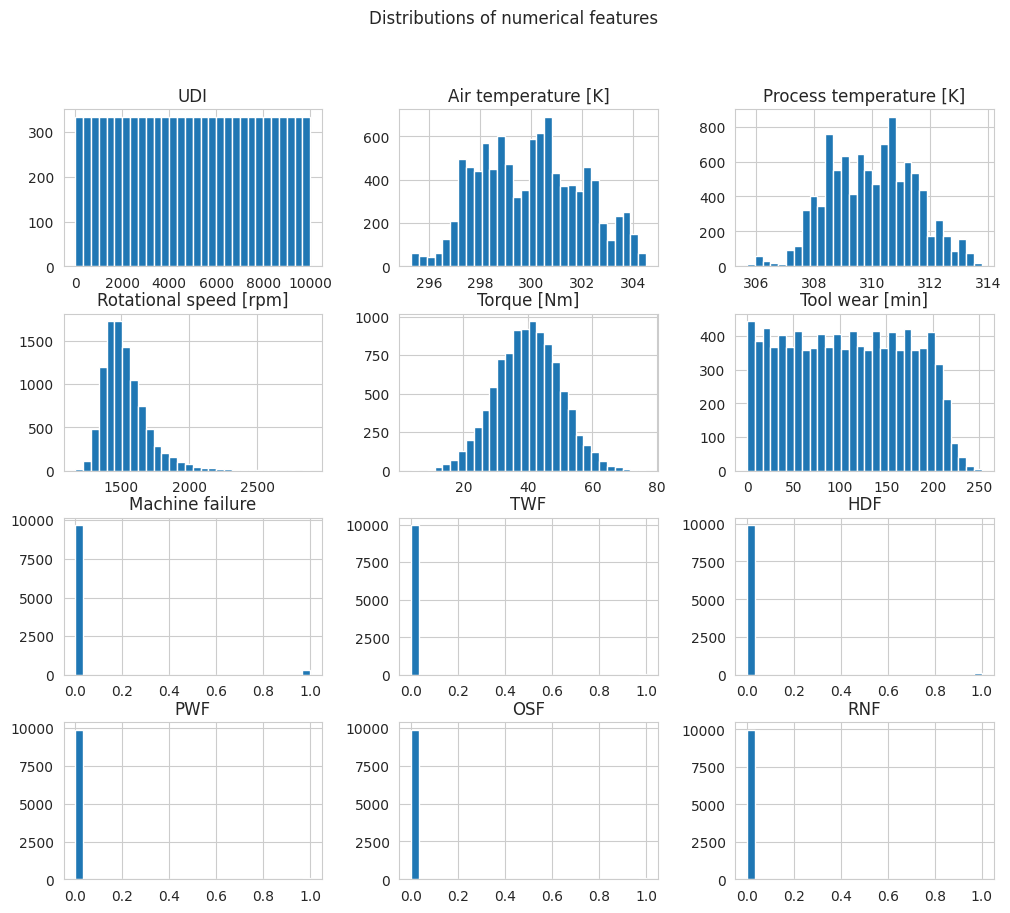

In [6]:
# 5. Visualize distributions of numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns

df[numeric_cols].hist(figsize=(12,10), bins=30)
plt.suptitle("Distributions of numerical features")
plt.show()


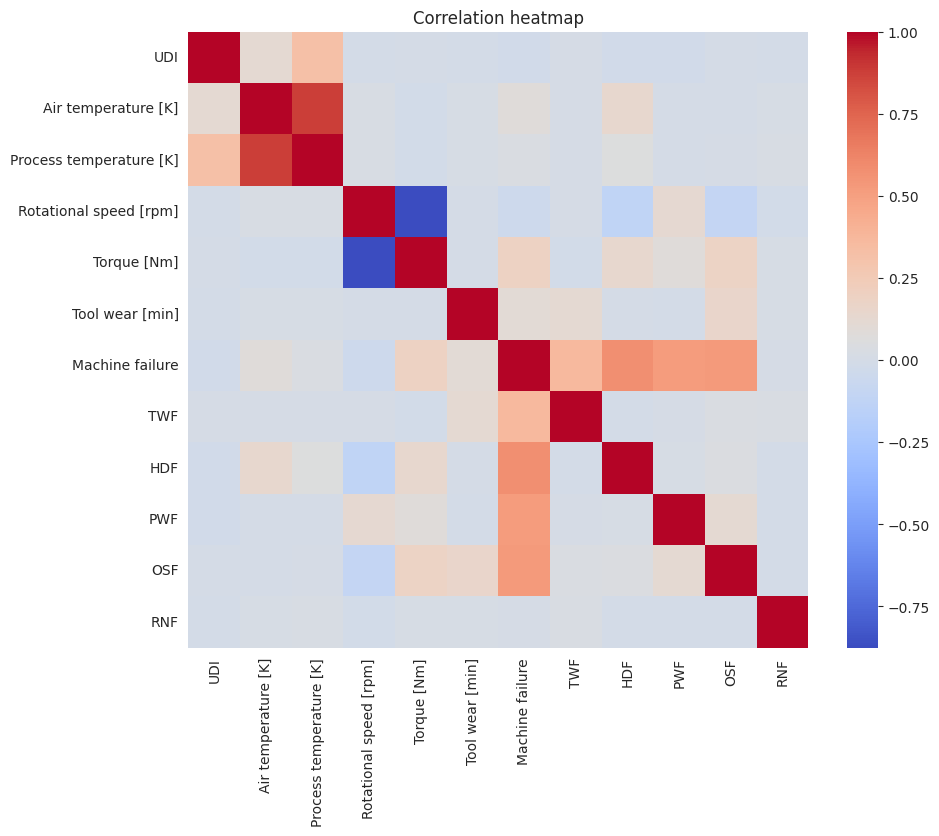

In [33]:
# 6. Correlation heatmap (numerical only)
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=False, cmap="coolwarm")
plt.title("Correlation heatmap")
plt.show()

In [34]:

new_panda = df.drop(columns=["Machine failure","UDI","Product ID"] )

In [35]:
# 8. Identify categorical features
cat_cols = new_panda.select_dtypes(include=["object"]).columns
print("Categorical features:", cat_cols.tolist())


Categorical features: ['Type']


In [36]:

new_panda = pd.get_dummies(new_panda, columns=["Type"], dtype=int)
new_panda

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,RNF,Type_H,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,0,1
1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,1,0
2,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,1,0
3,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,1,0
4,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,298.8,308.4,1604,29.5,14,0,0,0,0,0,0,0,1
9996,298.9,308.4,1632,31.8,17,0,0,0,0,0,1,0,0
9997,299.0,308.6,1645,33.4,22,0,0,0,0,0,0,0,1
9998,299.0,308.7,1408,48.5,25,0,0,0,0,0,1,0,0


In [37]:
# 9. Scale numeric features (important for neural nets)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(new_panda)

print("Scaled feature matrix shape:", new_panda.shape)

# 10. Final check
print("Mean (first 5 features):", X_scaled[:, :5].mean(axis=0))
print("Std (first 5 features):", X_scaled[:, :5].std(axis=0))

Scaled feature matrix shape: (10000, 13)
Mean (first 5 features): [-9.32232069e-16 -1.69393388e-15 -2.33058017e-16  5.42499379e-16
  1.05160325e-16]
Std (first 5 features): [1. 1. 1. 1. 1.]


In [38]:
target_cols = ["TWF","HDF","PWF","OSF","RNF"]
feature_cols = [c for c in new_panda.columns if c not in target_cols]
new_panda = new_panda[feature_cols+target_cols]
new_panda

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_H,Type_L,Type_M,TWF,HDF,PWF,OSF,RNF
0,298.1,308.6,1551,42.8,0,0,0,1,0,0,0,0,0
1,298.2,308.7,1408,46.3,3,0,1,0,0,0,0,0,0
2,298.1,308.5,1498,49.4,5,0,1,0,0,0,0,0,0
3,298.2,308.6,1433,39.5,7,0,1,0,0,0,0,0,0
4,298.2,308.7,1408,40.0,9,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,298.8,308.4,1604,29.5,14,0,0,1,0,0,0,0,0
9996,298.9,308.4,1632,31.8,17,1,0,0,0,0,0,0,0
9997,299.0,308.6,1645,33.4,22,0,0,1,0,0,0,0,0
9998,299.0,308.7,1408,48.5,25,1,0,0,0,0,0,0,0


In [41]:
new_panda.to_csv("ai4i2020formatted.csv", index=False)